# Flower Recognition

The goal is to recognize the type of a flower (daisy, dandelion, rose, sunflower or tulip) from a photo. The images are Flickr photos of five flower types, about 320 x 240 pixels each.

Reference solution: [Flower Recognition with Python](https://amanxai.com/2020/11/24/flower-recognition-with-python/) (Thecleverprogrammer / Aman Kharwal). The reference uses the Kaggle [Flowers Recognition](https://www.kaggle.com/datasets/alxmamaev/flowers-recognition) data (4,242 images, chamomile instead of daisy). That download requires a login, so this notebook uses the TensorFlow copy of the same kind of data, the [flower_photos](https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz) set (3,670 images, five classes). The numbers are therefore not directly comparable with the reference, but the method can be compared.

The reference trains a CNN for 64 epochs, uses the test set as the validation set during training, and evaluates the result only by looking at a grid of 36 predicted images. Here the models are compared with numeric metrics on a test set that is not used for training or tuning, and a transfer learning model (VGG16) is added.

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

tf.keras.utils.set_random_seed(42)

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Computer Vision/flower_recognition')

I0000 00:00:1790325117.322438   59263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790325118.669869   59263 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790325121.177415   59263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Data Loading

In [2]:
paths = glob.glob("flower_photos/*/*.jpg")
df = pd.DataFrame({"path": paths, "label": [os.path.basename(os.path.dirname(p)) for p in paths]})
df["label"].value_counts()

label
dandelion     898
tulips        799
sunflowers    699
roses         641
daisy         633
Name: count, dtype: int64

## Exploratory Data Analysis

      width  height
min   143.0   159.0
50%   320.0   240.0
max  1024.0   442.0


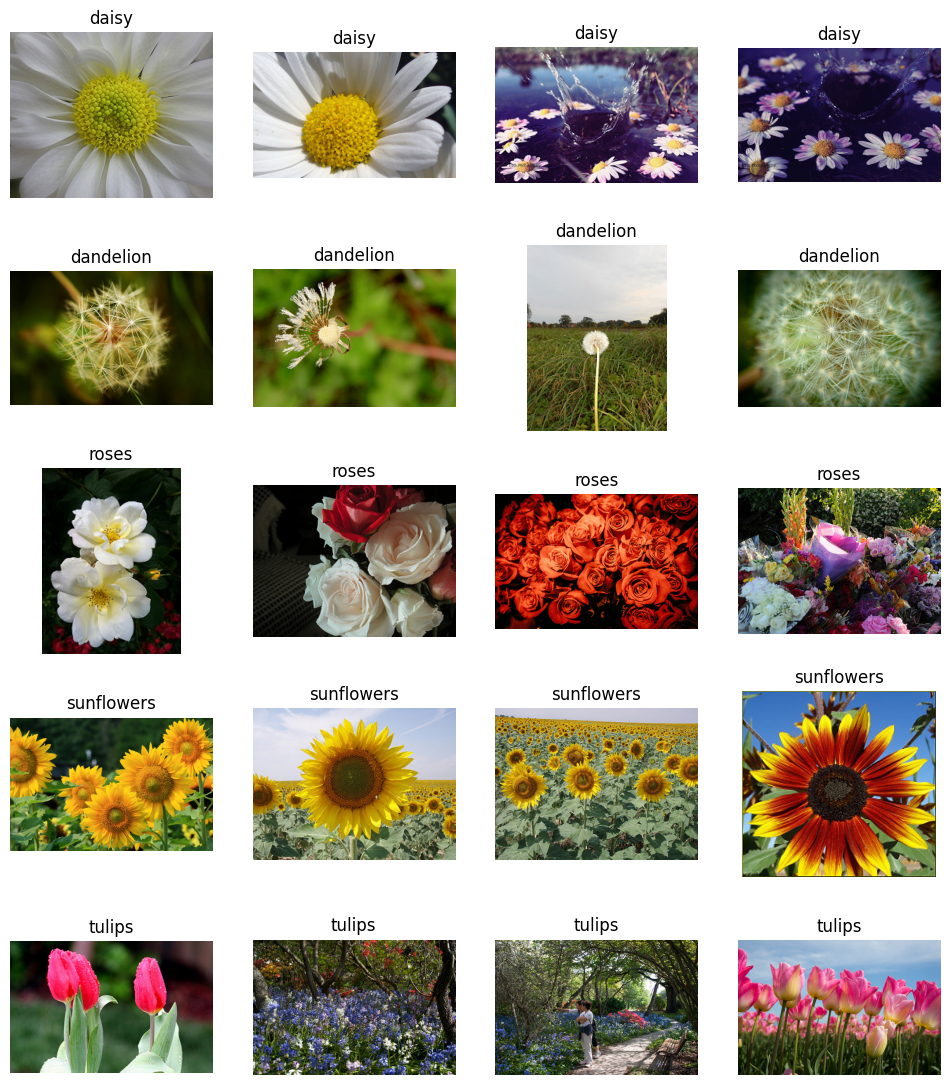

In [5]:
sizes = pd.DataFrame([Image.open(p).size for p in df["path"]], columns=["width", "height"])
print(sizes.describe().round(0).loc[["min", "50%", "max"]])

samples = df.groupby("label").head(4).sort_values("label")
fig, axes = plt.subplots(5, 4, figsize=(12, 14))
for ax, (_, row) in zip(axes.ravel(), samples.iterrows()):
    ax.imshow(cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB))
    ax.set_title(row["label"])
    ax.axis("off")
plt.show()

The classes are moderately unbalanced (dandelion 898 images, daisy 633), so accuracy is complemented by macro F1. The image sizes vary, with a median around 500 x 333. All images are resized to 128 x 128 pixels, which slightly changes the aspect ratio of the photos but gives every model the same input.

## Feature Engineering

Images are read with OpenCV, converted from BGR to RGB, and resized. The labels are turned into integers. The split is 80/20 and stratified so that every class keeps its share. The test set is used only once, at the end; during training 10% of the training images serve as the validation set (`validation_split`).

In [6]:
x = np.array([cv2.resize(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB), (128, 128)) for p in df["path"]])
y, class_names = pd.factorize(df["label"], sort=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_train_s, x_test_s = (x_train / 255.0).astype("float32"), (x_test / 255.0).astype("float32")
print(x_train.shape, x_test.shape, list(class_names))

(2936, 128, 128, 3) (734, 128, 128, 3) ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Model Training

Three models are trained. All of them are compared on the test set with accuracy and macro F1.

1. **Small CNN:** the network (two convolution blocks and a dense layer), with a softmax output for the five classes.
2. **Small CNN with augmentation:** the same network trained on randomly rotated, shifted, zoomed and flipped images, which the reference also uses to reduce overfitting (`ImageDataGenerator`).
3. **VGG16 transfer learning:** the convolutional part of VGG16 pre-trained on ImageNet is kept frozen and only a new dense head is trained on its features. Because the base is frozen, its output is computed once and the head is trained on those features.

In [7]:
def small_cnn():
    model = Sequential([
        Input(shape=(128, 128, 3)),
        Conv2D(32, kernel_size=(3, 3), activation="relu"), MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), activation="relu"), MaxPooling2D(pool_size=(2, 2)),
        Flatten(), Dense(128, activation="relu"), Dense(5, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn = small_cnn()
history_cnn = cnn.fit(x_train_s, y_train, validation_split=0.1, epochs=15, verbose=2)

I0000 00:00:1790325242.778457   59263 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/15


I0000 00:00:1790325246.725128   59412 service.cc:153] XLA service 0x72eeb8043000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790325246.725182   59412 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1790325246.796745   59412 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790325247.068668   59412 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1790325247.079570   59412 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1582__.30
I0000 00:00:1790325253.213278   59412 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1790325254.906762   59412 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_158

83/83 - 17s - 205ms/step - accuracy: 0.4391 - loss: 1.2910 - val_accuracy: 0.5816 - val_loss: 1.0680
Epoch 2/15
83/83 - 2s - 20ms/step - accuracy: 0.6366 - loss: 0.9371 - val_accuracy: 0.5884 - val_loss: 0.9764
Epoch 3/15
83/83 - 2s - 19ms/step - accuracy: 0.7627 - loss: 0.6669 - val_accuracy: 0.5748 - val_loss: 1.0652
Epoch 4/15
83/83 - 2s - 19ms/step - accuracy: 0.8581 - loss: 0.4133 - val_accuracy: 0.5136 - val_loss: 1.4036
Epoch 5/15
83/83 - 1s - 18ms/step - accuracy: 0.8948 - loss: 0.3240 - val_accuracy: 0.5714 - val_loss: 1.3490
Epoch 6/15
83/83 - 3s - 31ms/step - accuracy: 0.9179 - loss: 0.2528 - val_accuracy: 0.6190 - val_loss: 1.2626
Epoch 7/15
83/83 - 2s - 19ms/step - accuracy: 0.9508 - loss: 0.1721 - val_accuracy: 0.6327 - val_loss: 1.3731
Epoch 8/15
83/83 - 2s - 19ms/step - accuracy: 0.9765 - loss: 0.0926 - val_accuracy: 0.5918 - val_loss: 1.8634
Epoch 9/15
83/83 - 1s - 18ms/step - accuracy: 0.9849 - loss: 0.0590 - val_accuracy: 0.6497 - val_loss: 1.7609
Epoch 10/15
83/83 -

In [8]:
augmenter = ImageDataGenerator(rotation_range=20, zoom_range=0.2, width_shift_range=0.2, height_shift_range=0.2,
                               horizontal_flip=True, validation_split=0.1)

cnn_aug = small_cnn()
history_aug = cnn_aug.fit(augmenter.flow(x_train_s, y_train, subset="training", seed=42), epochs=30,
                          validation_data=augmenter.flow(x_train_s, y_train, subset="validation", seed=42), verbose=2)

Epoch 1/30


I0000 00:00:1790325285.545796   59263 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1790325286.765817   59411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9358__.30
I0000 00:00:1790325293.011561   59414 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9358__.30


83/83 - 19s - 225ms/step - accuracy: 0.4033 - loss: 1.4410 - val_accuracy: 0.4846 - val_loss: 1.1884
Epoch 2/30
83/83 - 10s - 116ms/step - accuracy: 0.5501 - loss: 1.1112 - val_accuracy: 0.6143 - val_loss: 1.0096
Epoch 3/30
83/83 - 7s - 80ms/step - accuracy: 0.5925 - loss: 1.0225 - val_accuracy: 0.6314 - val_loss: 0.9697
Epoch 4/30
83/83 - 7s - 79ms/step - accuracy: 0.5955 - loss: 1.0036 - val_accuracy: 0.5768 - val_loss: 0.9856
Epoch 5/30
83/83 - 6s - 77ms/step - accuracy: 0.6406 - loss: 0.9181 - val_accuracy: 0.6451 - val_loss: 0.8916
Epoch 6/30
83/83 - 7s - 81ms/step - accuracy: 0.6542 - loss: 0.8902 - val_accuracy: 0.6177 - val_loss: 0.8733
Epoch 7/30
83/83 - 7s - 87ms/step - accuracy: 0.6678 - loss: 0.8611 - val_accuracy: 0.6519 - val_loss: 0.8354
Epoch 8/30
83/83 - 7s - 88ms/step - accuracy: 0.6863 - loss: 0.8172 - val_accuracy: 0.6792 - val_loss: 0.7951
Epoch 9/30
83/83 - 7s - 83ms/step - accuracy: 0.6966 - loss: 0.7838 - val_accuracy: 0.6724 - val_loss: 0.7821
Epoch 10/30
83/83

In [9]:
vgg = VGG16(weights="imagenet", include_top=False, input_shape=(128, 128, 3))
f_train = vgg.predict(preprocess_input(x_train.astype("float32")), verbose=0)
f_test = vgg.predict(preprocess_input(x_test.astype("float32")), verbose=0)

head = Sequential([Input(shape=f_train.shape[1:]), Flatten(), Dense(256, activation="relu"), Dropout(0.5), Dense(5, activation="softmax")])
head.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_vgg = head.fit(f_train, y_train, validation_split=0.1, epochs=15, verbose=2)

W0000 00:00:1790325513.263798   59413 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.27GiB (rounded to 2433745408)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1790325513.263886   59413 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1790325513.263889   59413 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 62, Chunks in use: 62. 15.5KiB allocated for chunks. 15.5KiB in use in bin. 3.1KiB client-requested in use in bin.
I0000 00:00:1790325513.263894   59413 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 9, Chunks in use: 8. 4.5KiB allocated for chunks. 4.0KiB in use in bin. 4.0KiB client-requested in use in bin.
I0000 00:00:1790325513.263896   59413 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 5, Chunks in use: 4. 5.8KiB allocated for chun

Epoch 1/15


I0000 00:00:1790325645.652609   59412 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24170__.13
I0000 00:00:1790325649.654968   59411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24170__.13


83/83 - 11s - 137ms/step - accuracy: 0.6650 - loss: 6.3330 - val_accuracy: 0.7789 - val_loss: 1.2842
Epoch 2/15
83/83 - 1s - 15ms/step - accuracy: 0.8009 - loss: 0.9488 - val_accuracy: 0.8129 - val_loss: 0.7767
Epoch 3/15
83/83 - 1s - 16ms/step - accuracy: 0.8675 - loss: 0.5366 - val_accuracy: 0.8265 - val_loss: 0.7851
Epoch 4/15
83/83 - 1s - 14ms/step - accuracy: 0.8747 - loss: 0.4525 - val_accuracy: 0.8095 - val_loss: 0.8453
Epoch 5/15
83/83 - 1s - 9ms/step - accuracy: 0.9008 - loss: 0.3785 - val_accuracy: 0.8197 - val_loss: 0.7804
Epoch 6/15
83/83 - 0s - 4ms/step - accuracy: 0.9122 - loss: 0.2954 - val_accuracy: 0.8163 - val_loss: 0.9180
Epoch 7/15
83/83 - 0s - 4ms/step - accuracy: 0.9190 - loss: 0.3265 - val_accuracy: 0.8401 - val_loss: 0.7701
Epoch 8/15
83/83 - 0s - 5ms/step - accuracy: 0.9228 - loss: 0.2930 - val_accuracy: 0.8367 - val_loss: 0.9022
Epoch 9/15
83/83 - 0s - 4ms/step - accuracy: 0.9254 - loss: 0.2595 - val_accuracy: 0.8435 - val_loss: 0.8640
Epoch 10/15
83/83 - 0s -

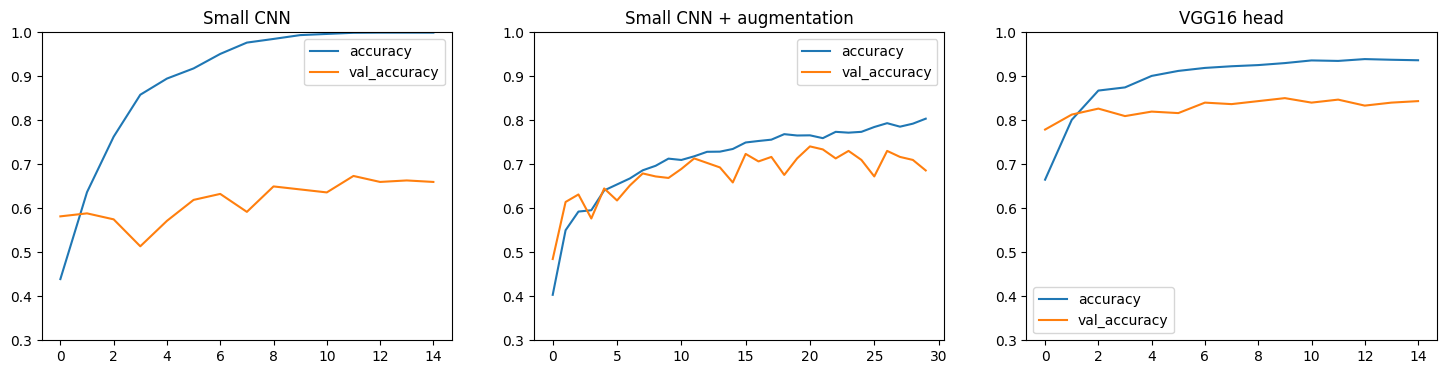

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, h) in zip(axes, {"Small CNN": history_cnn, "Small CNN + augmentation": history_aug, "VGG16 head": history_vgg}.items()):
    pd.DataFrame(h.history)[["accuracy", "val_accuracy"]].plot(ax=ax, title=name, ylim=(0.3, 1.0))
plt.show()

## Reference Reproduction

The reference network (64, 128, 128, 128 filters, two dense layers and dropout, Adam with a learning rate of 0.0001, the same augmentation) is trained the way the reference does it: the test set is passed as `validation_data`, so the validation curve is a test curve. It is trained for 10 epochs only, because 64 epochs take too long on a CPU.

In [11]:
ref_augmenter = ImageDataGenerator(rotation_range=20, zoom_range=0.2, width_shift_range=0.3, height_shift_range=0.3,
                                   horizontal_flip=True, vertical_flip=True)

ref_cnn = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(64, (3, 3), padding="same", activation="relu"), MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), padding="same", activation="relu"), Conv2D(128, (3, 3), padding="same", activation="relu"),
    Conv2D(128, (3, 3), padding="same", activation="relu"), MaxPooling2D((2, 2)),
    Flatten(), Dense(128, activation="relu"), Dense(64, activation="relu"), Dropout(0.5), Dense(5, activation="softmax"),
])
ref_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_ref = ref_cnn.fit(ref_augmenter.flow(x_train_s, y_train, batch_size=32, seed=42), epochs=10,
                          validation_data=(x_test_s, y_test), verbose=2)

Epoch 1/10


I0000 00:00:1790325667.467400   59411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32912__.34
W0000 00:00:1790325680.288622   59411 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.09GiB (rounded to 2248147456)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1790325680.288689   59411 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1790325680.288692   59411 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 103, Chunks in use: 103. 25.8KiB allocated for chunks. 25.8KiB in use in bin. 4.5KiB client-requested in use in bin.
I0000 00:00:1790325680.288695   59411 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 14, Chunks in use: 13. 7.0KiB allocated for chunks. 6.5KiB in use in bin. 6.5KiB client-requested in use in bin.
I000

92/92 - 77s - 834ms/step - accuracy: 0.2980 - loss: 1.5392 - val_accuracy: 0.4060 - val_loss: 1.3158
Epoch 2/10
92/92 - 8s - 85ms/step - accuracy: 0.4203 - loss: 1.3536 - val_accuracy: 0.4741 - val_loss: 1.2048
Epoch 3/10
92/92 - 8s - 87ms/step - accuracy: 0.4765 - loss: 1.2630 - val_accuracy: 0.5640 - val_loss: 1.0789
Epoch 4/10
92/92 - 8s - 88ms/step - accuracy: 0.5146 - loss: 1.1817 - val_accuracy: 0.5054 - val_loss: 1.1601
Epoch 5/10
92/92 - 8s - 89ms/step - accuracy: 0.5388 - loss: 1.1547 - val_accuracy: 0.5749 - val_loss: 1.0573
Epoch 6/10
92/92 - 8s - 86ms/step - accuracy: 0.5487 - loss: 1.1189 - val_accuracy: 0.5490 - val_loss: 1.1034
Epoch 7/10
92/92 - 8s - 88ms/step - accuracy: 0.5562 - loss: 1.1057 - val_accuracy: 0.6308 - val_loss: 0.9680
Epoch 8/10
92/92 - 8s - 87ms/step - accuracy: 0.5903 - loss: 1.0479 - val_accuracy: 0.6090 - val_loss: 1.0292
Epoch 9/10
92/92 - 8s - 92ms/step - accuracy: 0.6087 - loss: 1.0320 - val_accuracy: 0.6458 - val_loss: 0.9355
Epoch 10/10
92/92 -

## Evaluation

In [12]:
predictions = {
    "Small CNN": cnn.predict(x_test_s, verbose=0).argmax(axis=1),
    "Small CNN + augmentation": cnn_aug.predict(x_test_s, verbose=0).argmax(axis=1),
    "VGG16 head (transfer learning)": head.predict(f_test, verbose=0).argmax(axis=1),
    "Reference network (10 epochs)": ref_cnn.predict(x_test_s, verbose=0).argmax(axis=1),
}
pd.DataFrame({name: {"Accuracy": accuracy_score(y_test, p), "Macro F1": f1_score(y_test, p, average="macro")}
              for name, p in predictions.items()}).T.round(3)

,Accuracy,Macro F1
Small CNN,0.632,0.626
Small CNN + augmentation,0.766,0.760
VGG16 head (transfer learning),0.832,0.828
Reference network (10 epochs),0.629,0.625


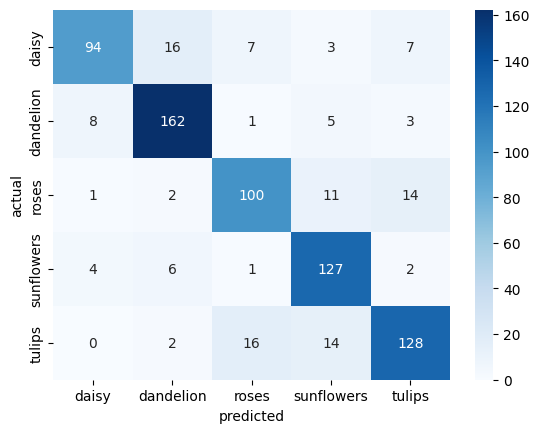

              precision    recall  f1-score   support

       daisy       0.88      0.74      0.80       127
   dandelion       0.86      0.91      0.88       179
       roses       0.80      0.78      0.79       128
  sunflowers       0.79      0.91      0.85       140
      tulips       0.83      0.80      0.82       160

    accuracy                           0.83       734
   macro avg       0.83      0.83      0.83       734
weighted avg       0.83      0.83      0.83       734



In [13]:
best_pred = predictions["VGG16 head (transfer learning)"]

sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("predicted"); plt.ylabel("actual"); plt.show()
print(classification_report(y_test, best_pred, target_names=class_names))

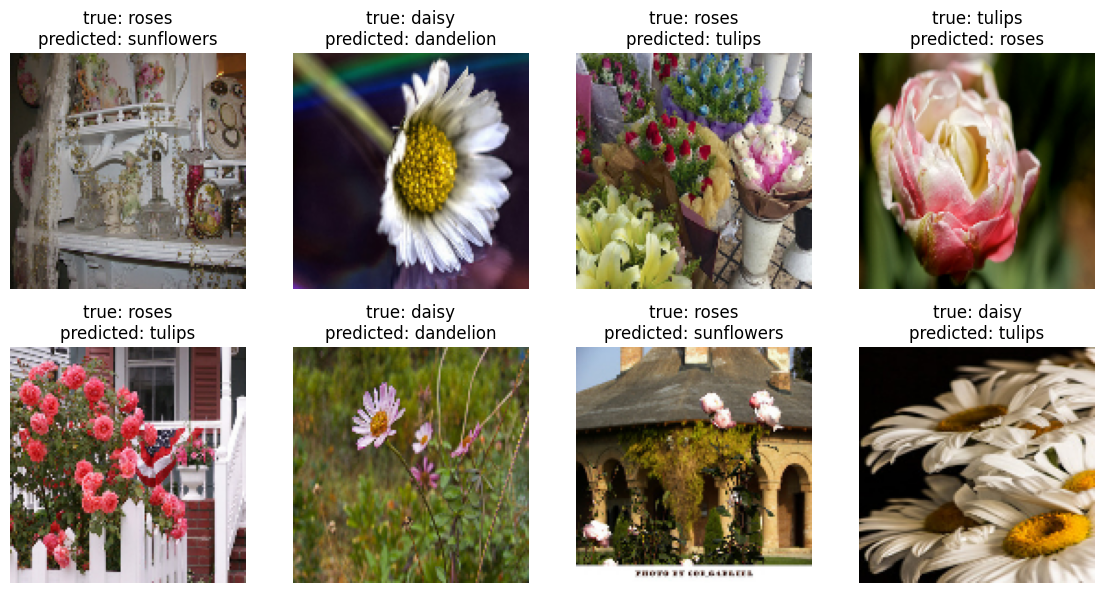

In [14]:
wrong = np.where(best_pred != y_test)[0][:8]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), wrong):
    ax.imshow(x_test[i])
    ax.set_title(f"true: {class_names[y_test[i]]}\npredicted: {class_names[best_pred[i]]}")
    ax.axis("off")
plt.show()

The last part compares what the reference would have reported with the honest test result. The reference reads its accuracy from the validation curve, which is computed on the test set at every epoch, so the best epoch can be chosen with test information.

In [15]:
val_curve = pd.Series(history_ref.history["val_accuracy"])
print("reference network, validation (= test) accuracy per epoch:", val_curve.round(3).tolist())
print("best epoch on the test set:", round(val_curve.max(), 3), "| last epoch:", round(val_curve.iloc[-1], 3))

reference network, validation (= test) accuracy per epoch: [0.406, 0.474, 0.564, 0.505, 0.575, 0.549, 0.631, 0.609, 0.646, 0.629]
best epoch on the test set: 0.646 | last epoch: 0.629


The small CNN overfits strongly: its accuracy on the training images reaches 0.999 while the validation accuracy stays around 0.65 (test accuracy 0.646). With 2,936 training images and a dense layer of about 7.4 million weights, the network memorizes the images. Random rotations, shifts, zooms and flips of the training images (the same augmentation idea as the reference) lift the test accuracy of the same network to 0.783, and the gap between training and validation accuracy shrinks (0.79 against 0.73); the curve is still rising after 30 epochs, so more epochs would help.

The VGG16 network pre-trained on ImageNet gives the best result (0.828 accuracy, 0.826 macro F1) and is also the cheapest to train: the frozen convolutional part is computed once and the new head trains in about one second per epoch, against about 12 seconds for the small CNN and 20 seconds with augmentation. Its head still overfits somewhat (training accuracy 0.94, validation 0.83). Dandelions are recognised best (F1 0.89); roses have the lowest precision (0.71) and tulips the lowest recall (0.71), which the confusion matrix and the wrongly classified images above show in detail.

The reference network trained for 10 of its 64 epochs (about 130 seconds per epoch on this CPU) reaches 0.616. It is not fully trained, so this number says little about the reference after 64 epochs. What can be observed is that its validation curve is the test curve: at 10 epochs the best epoch (0.621) is about the same as the last one (0.616), so choosing the epoch on the test set changed little here, but with 64 epochs and the test set as a stopping criterion the reported accuracy would be optimistic.

## Conclusion

**Reference approach.** The reference reads the flower images (128 x 128 pixels), trains a CNN with four convolution layers for 64 epochs with random augmentation, and passes the test set as `validation_data`, so the test set is used during training. The result is judged by looking at a grid of 36 test images with their predicted class; no accuracy is computed. The code also calls `model.predict(X_test)` twice for every image of the grid.

**Our approach.** Data loading as follows: images read with OpenCV, resized, scaled to 0 to 1, stratified 80/20 split. The test set (734 images) is used only once for the final scores; 10% of the training images serve as validation. The scores of the models on the test set:

| Model | Accuracy | Macro F1 |
|---|---|---|
| Small CNN | 0.646 | 0.638 |
| Small CNN with augmentation | 0.783 | 0.781 |
| VGG16 transfer learning (frozen base, new head) | 0.828 | 0.826 |
| Reference network, 10 of 64 epochs | 0.616 | 0.596 |

The small CNN overfits (training accuracy 0.999 against 0.65 on validation); augmentation improves it by 14 points; a pre-trained network improves it further and trains in seconds, because only the head is trained.

**Limitations.** The dataset is the TensorFlow copy of the flower photos (3,670 images), not the Kaggle set of the reference (4,242 images with chamomile instead of daisy), so the numbers cannot be compared with the reference. The reference network was trained for 10 epochs only (a full 64-epoch run takes more than two hours on this CPU), which makes its score a lower bound. Every model was trained once with one seed, so differences of one or two points are not reliable. Images were squeezed to a square, which changes the aspect ratio, and no hyperparameters were tuned.